In [1]:
import os
import sys
sys.path.append("C:/Users/PC-EIAD209/Desktop/AnaKei/NIPD-AI")
#sys.path.append("C:\\Users\\"+os.getlogin()+"\\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\\PainClassifier")
from my_data_generator_final import *

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
import h5py
import warnings
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_fscore_support as score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from datetime import datetime
import scipy as sp
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import auc, roc_curve
from itertools import cycle
from sklearn.metrics import RocCurveDisplay
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Reshape, Conv3D, MaxPooling3D, Flatten, Dropout, GlobalAveragePooling3D, concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
import imageio_ffmpeg
from tensorflow.keras.applications.vgg16 import VGG16


#from keras.regularizers import l2
import cv2
#from keras import initializers
#from keras.layers import LeakyReLU
#from keras.layers import BatchNormalization
import tensorflow as tf
#from keras import losses
import matplotlib as mpl
import imageio_ffmpeg
#nuevo
from tensorflow.keras.regularizers import l2
from tensorflow.keras import initializers, losses
from tensorflow.keras.layers import LeakyReLU, BatchNormalization


from tensorflow.keras.optimizers import SGD
import wandb
from wandb.integration.keras import WandbCallback
import gc
#from numba import cuda   nota: no se usa
from tensorflow.keras.optimizers.schedules import ExponentialDecay



In [3]:
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from hirescam import HiResCAM


In [4]:
import wandb
from wandb.integration.keras import keras

old_from_keras = getattr(wandb.Graph, "from_keras", None)

def safe_from_keras(model, *args, **kwargs):
    print("W&B Graph visualization desactivada (inbound_layers incompatibles con Keras 3.x).")
    return None  # evita que se intente generar el grafo

if old_from_keras is not None:
    wandb.Graph.from_keras = safe_from_keras

In [5]:
import wandb
from wandb.integration.keras import WandbCallback
import keras

wandb.keras = None  # Desactiva funciones viejas de grafo

class SafeWandbCallback(WandbCallback):
    """Versión segura de WandbCallback compatible con Keras moderno."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._model = None  # ← previene el AttributeError

    def set_model(self, model):
        try:
            self._model = model  # almacena referencia sin conflicto
            super().set_model(model)
        except Exception as e:
            print(f"Se omitió un error interno de W&B-Keras: {e}")


In [6]:
physical_devices = tf.config.list_physical_devices('GPU')
try:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
  # Invalid device or cannot modify virtual devices once initialized.
  pass

In [7]:
# Mixed precision training

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('float32')

#DirectML no se lleva com mixedfloat16
#mixed_precision.set_global_policy('mixed_float16')

In [8]:
def VGG16_3D(blocks):
        
    inputs = Input(shape=(42, 65, 29), name='input_layer')
    x = Reshape(target_shape=[42, 65, 29, 1], name='input_x_3d_volumes')(inputs)

    if blocks == 1:
        print("entra al 1")
        #batch_norm
        x = BatchNormalization()(x)
        # 1st Conv Block
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.GlobalAveragePooling3D()(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        
    elif blocks == 2:
        print("entra al 2")
        #batch_norm
        x = BatchNormalization()(x)
        # 1st Conv Block
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
            
        #batch_norm
        x = BatchNormalization()(x)
        # 2nd Conv Block
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.GlobalAveragePooling3D()(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        
    elif blocks == 3:
        print("entra al 3")
        #batch_norm
        x = BatchNormalization()(x)
        # 1st Conv Block
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
            
        #batch_norm
        x = BatchNormalization()(x)
        # 2nd Conv Block
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        
        #batch_norm
        x = BatchNormalization()(x)
        # 3rd Conv block  
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x) 
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x) 
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x) 
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.GlobalAveragePooling3D()(x)
        x = tf.keras.layers.Dropout(0.5)(x)
        
    elif blocks == 4:
        print("entra al 4")
        #batch_norm
        x = BatchNormalization()(x)
        # 1st Conv Block
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
            
        #batch_norm
        x = BatchNormalization()(x)
        # 2nd Conv Block
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        #x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        
        #batch_norm
        x = BatchNormalization()(x)
        # 3rd Conv block  
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x) 
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x) 
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x) 
        #x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.2)(x)
        
        #batch_norm
        x = BatchNormalization()(x)
        # 4th Conv block
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer='l2')(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        #x = tf.keras.layers.GlobalAveragePooling3D()(x)
        x = tf.keras.layers.Dropout(0.5)(x)

    elif blocks == 5:
        print("entra al 5")
        #batch_norm
        #x = BatchNormalization()(x)
        # 1st Conv Block
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = Conv3D(filters =64, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = BatchNormalization()(x)
        x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.1)(x)
            
        #batch_norm
        #x = BatchNormalization()(x)
        # 2nd Conv Block
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = Conv3D (filters =128, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = BatchNormalization()(x)
        #x = MaxPooling3D(pool_size =2, strides =1, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        
        #batch_norm
        #x = BatchNormalization()(x)
        # 3rd Conv block  
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x) 
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x) 
        x = Conv3D (filters =256, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x) 
        x = BatchNormalization()(x)
        #x = MaxPooling3D(pool_size =2, strides =1, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.1)(x)
        
        #batch_norm
        #x = BatchNormalization()(x)
        # 4th Conv block
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = BatchNormalization()(x)
        #x = MaxPooling3D(pool_size =2, strides =1, padding ='same')(x)
        x = tf.keras.layers.Dropout(0.1)(x)
    
        #batch_norm
        #x = BatchNormalization()(x)
        # 5th Conv block
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = Conv3D (filters =512, kernel_size =3, padding ='same', activation='relu',kernel_regularizer=tf.keras.regularizers.L2(l2=0.001))(x)
        x = BatchNormalization()(x)
        #x = MaxPooling3D(pool_size =2, strides =2, padding ='same')(x)
        x = tf.keras.layers.GlobalAveragePooling3D()(x)
        x = tf.keras.layers.Dropout(0.1)(x)
    
    # Fully connected layers  
    x = Flatten()(x) 
    x = Dense(units = 1024, activation ='relu',kernel_regularizer='l2')(x)
    #x = tf.keras.layers.Dropout(0.5)(x)
    x = Dense(units = 1024, activation ='relu',kernel_regularizer='l2')(x) 
    x = tf.keras.layers.Dropout(0.3)(x)
    output = Dense(units = 2,activation ='softmax',kernel_regularizer='l2')(x)
    
    # creating the model
    VGG_3d_model = Model (inputs=inputs, outputs =output)
    #model.summary()

    return VGG_3d_model

def set_pretrained_weigths(VGG_3d_model):
    #VGG 16 with weights from Imagenet
    pretrained_model = tf.keras.applications.VGG16(
        include_top=False,
        weights="imagenet",
        pooling='avg',
        input_shape = (42, 65, 3)
    )
    
    #conv layers on VGG_3d_model
    layers_conv = []
    for j in range(len(VGG_3d_model.layers)):
        if "conv3d" in str(VGG_3d_model.layers[j]):
            layers_conv.append(j)
    layers_conv_pretrained = []
    for j in range(len(pretrained_model.layers)):
        if "Conv2D" in str(pretrained_model.layers[j]):
            layers_conv_pretrained.append(j)
    
    for i in range(len(layers_conv)):
        if "Conv2D" in str(pretrained_model.layers[layers_conv_pretrained[i]]):
            if i == 0:
                w = pretrained_model.layers[layers_conv_pretrained[i]].get_weights()[0].sum(axis=2, keepdims=True)
            else:
                w = pretrained_model.layers[layers_conv_pretrained[i]].get_weights()[0]
                
            w3d=[]
            
            w = np.reshape(w,(3,3,-1),order='F')
            for j in range(len(w[0,0,:])):
                for k in range(3):
                    w3d.append(w[:,:,j])
            w3d = np.transpose(w3d, (1,2,0))
            
            new_weights = np.reshape(w3d, np.array(VGG_3d_model.layers[layers_conv[i]].get_weights()[0]).shape,order='F')
            new_bias = pretrained_model.layers[layers_conv_pretrained[i]].get_weights()[1]
            
            WnB = []
            WnB.append(new_weights)
            WnB.append(new_bias)
    
            VGG_3d_model.layers[layers_conv[i]].set_weights(WnB)

    del pretrained_model, w, WnB, new_weights, new_bias, w3d

In [9]:
def confusionmatrix_multiclass(y_test,pred):
    cm = confusion_matrix(y_test, (np.rint(preds)).astype(int) )
    group_names = ['True baseline','False Baseline','False Baseline',   
                   'False week 1','Truec','False Week 1',
                  'False week 7','False week 7','True week 7']
    group_counts = ["{0:0.0f}".format(value) for value in
                    cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         np.ndarray.flatten(cm/(np.sum(cm,axis=1).reshape(3,1)))]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
              zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(3,3)
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels = ['Baseline','Week 1','Week 7'] ,yticklabels = ['Baseline','Week 1','Week 7'])
    plt.show()

def confusionmatrix(y_test,preds):
    #Construct the Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    group_names = ['True Male','False Male','False Female','True Female']
    group_counts = ["{0:0.0f}".format(value) for value in
                    cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         np.ndarray.flatten(cm/(np.sum(cm,axis=1).reshape(2,1)))]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
              zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels = ['MALE','FEMALE'] ,yticklabels = ['MALE','FEMALE'])
    plt.show()
    return sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels = ['MALE','FEMALE'] ,yticklabels = ['MALE','FEMALE'])
    
def confusionmatrix_binary(y_test, preds):
    cm = confusion_matrix(y_test, preds)
    group_names = ['True baseline','False baseline','False Week 1','True Week 1']
    group_counts = ["{0:0.0f}".format(value) for value in
                    cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         np.ndarray.flatten(cm/(np.sum(cm,axis=1).reshape(2,1)))]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
              zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', xticklabels = ['MALE','FEMALE'] ,yticklabels = ['MALE','FEMALE'])
    plt.show()

def ROC(probs,y_test): #binary
    #Classification Area under curve
     warnings.filterwarnings('ignore')
             
     auc = roc_auc_score(y_test, probs)
     print('AUC - Test Set: %.2f%%' % (auc*100))
    
     # calculate roc curve
     fpr, tpr, thresholds = roc_curve(y_test, probs)
     # plot no skill
     plt.plot([0, 1], [0, 1], linestyle='--')
     # plot the roc curve for the model
     plt.plot(fpr, tpr, marker='.')
     plt.xlabel('False positive rate')
     plt.ylabel('Sensitivity/ Recall')
     # show the plot
     plt.show()
    
     probs = (np.rint(probs)).astype(int)   
        
     precision = precision_score(y_test, probs)
     print('Precision: %f' % precision)
     # recall: tp / (tp + fn)
     recall = recall_score(y_test, probs)
     print('Recall: %f' % recall)
     # f1: tp / (tp + fp + fn)
     f1 = f1_score(y_test, probs)
     print('F1 score: %f' % f1)
        
def ROC_multiclass(model, y_test, n_class):
    #y_test: array size (# of subjects, ) with classes 
    #pretrained model to be evaluated 
    
    label_binarizer = LabelBinarizer().fit(y_test)
    y_onehot_test = label_binarizer.transform(y_test)
    y_onehot_test.shape  # (n_samples, n_classes)

    y_score = model.predict(X_test) # y_score is onehot
    
    # store the fpr, tpr, and roc_auc for all averaging strategies
    fpr, tpr, roc_auc = dict(), dict(), dict()
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['micro']:.2f}")
    
    n_classes = n_class
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr_grid = np.linspace(0.0, 1.0, 1000)

    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation

    # Average it and compute AUC
    mean_tpr /= n_classes

    fpr["macro"] = fpr_grid
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    print(f"Macro-averaged One-vs-Rest ROC AUC score:\n{roc_auc['macro']:.2f}")
    
    target_names = ['Naive','Week1','Week7']

    fig, ax = plt.subplots(figsize=(6, 6))

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
        color="deeppink",
        linestyle=":",
        linewidth=4,
    )

    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
        color="navy",
        linestyle=":",
        linewidth=4,
    )

    colors = cycle(["aqua", "darkorange", "cornflowerblue"])
    for class_id, color in zip(range(n_classes), colors):
        RocCurveDisplay.from_predictions(
            y_onehot_test[:, class_id],
            y_score[:, class_id],
            name=f"ROC curve for {target_names[class_id]}",
            color=color,
            ax=ax,
            plot_chance_level=(class_id == 2),
        )

    _ = ax.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title="Extension of Receiver Operating Characteristic\nto One-vs-Rest multiclass",
    )
    
# plot diagnostic learning curves
def summarize_diagnostics(histories):
    c = ['b','g','r','c','m','y','k','w']
    ltr = ['fold 1(train)','fold 2(train)','fold 3(train)','fold 4(train)','fold 5(train)']
    lts = ['fold 1(val)','fold 2(val)','fold 3(val)','fold 4(val)','fold 5(val)']
    for i in range(len(histories)):
        # plot loss
        plt.subplot(2, 1, 1)
        plt.title('Cross Entropy Loss')
        plt.plot(histories[i].history['loss'], color=c[i], label=ltr[i], linestyle="-")
        plt.plot(histories[i].history['val_loss'], color=c[i], label=lts[i], linestyle="--")
        # plot accuracy
        plt.subplot(2, 1, 2)
        plt.title('Classification Accuracy')
        plt.plot(histories[i].history['Accuracy'], color=c[i], label=ltr[i], linestyle="-")
        plt.plot(histories[i].history['val_Accuracy'], color=c[i], label=lts[i], linestyle="--")
    plt.legend()
    plt.show()

# summarize model performance
def summarize_performance(scores):
    # print summary
    print('Accuracy: mean=%.3f std=%.3f, n=%d' % (np.mean(scores)*100, np.std(scores)*100, len(scores)))
    # box and whisker plots of results
    plt.boxplot(scores)
    plt.show() 

In [10]:
male = [57, 
        #59,
        60,73,74,93,94,95,96,98,99,100]
female = [49,50,51,52,65,66,77,78,79,80,81,82,
          #83
         ]

y_male = np.ones(len(male))
y_female = np.zeros(len(female))

subjects = np.array(male+female)
labels = np.array(list(y_male)+list(y_female))
sessions = [3]
MRI_type = "func"
functional_type = "dist"

#Pretrained model to re start weights from at every fold
baseModel = VGG16_3D(5)
set_pretrained_weigths(baseModel)

#Model that is going to be train and re started every fold
CNN = VGG16_3D(5)


entra al 5
entra al 5


In [11]:
rootpath1 = "C:/Users/L03117947/Downloads/Kerensa/Computadora Prof.Omar/sigma_files/sigma_files/SIGMA_resam_InVivo_Brain_Template_Masked.nii"
img = nib.load(rootpath1)
data_grad_completo = img.get_fdata()
print(data_grad_completo.shape)
#Mascara base
mask_nii = "C:/Users/L03117947/Downloads/Kerensa/Computadora Prof.Omar/sigma_files/sigma_files/SIGMA_resam_InVivo_Brain_Mask.nii"
mask_nii = nib.load(mask_nii)
mask = mask_nii.get_fdata()
mask = mask > 0

(48, 81, 48)



=== Bootstrapping Run 1/1 ===
Run # 1


wandb: Currently logged in as: a01642230 (mansoor35) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to create root directory C:/Users/103087364/wandb_runs
wandb: WARNING Falling back to temporary directory C:\Users\L03117~1\AppData\Local\Temp.


holaaaa, se metio al mask and bold
SE METIO AL DISTTTTTTTTTT
SE METIO AL LOGIN
sesions:  [3]
SESION:  3
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  57
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  60
Se metió al 68
j:  50
Se metió al 68
j:  66
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
AHHHHHHHHHHHHHHHHHH [['R:/preprocess_batch-002/commonspace_bold/_scan_info_subject_id082.session03_split_name_sub-082_ses-03_desc-o_T2w/_run_None/sub-082_ses-03_task-dist_desc-oa_bold_autobox_combined.nii.gz', 'R:/preprocess_batch-002_rest/bold_datasink/commonspace_mask/_scan_info_subject_id082.session03_split_name_sub-082_ses-03_desc-o_T2w/_run_None/sub-082_ses-03_task-rest_desc-oa_bold_autobox_EPI_brain_mask.nii.gz'], ['R:/preprocess_batch-002/commonspace_bold/_scan_info_subject_id093.session03_split_name_sub-093_ses-03_desc-o_T2w/_run_None/sub-093_ses-03_task-dist_desc-oa_bold_autobox_combined.nii.gz', 'R:/pr

wandb: WARNING WandbCallback is deprecated and will be removed in a future release. Please use the WandbMetricsLogger, WandbModelCheckpoint, and WandbEvalCallback callbacks instead. See https://docs.wandb.ai/guides/integrations/keras for more information.


Training
Starting VGG 16 3D-----------------------------------------------------
Epoch 1/10
W&B Graph visualization desactivada (inbound_layers incompatibles con Keras 3.x).
418/418 [==============================] - 1396s 3s/step - loss: 20.4964 - Accuracy: 0.6879 - val_loss: 18.6757 - val_Accuracy: 0.3000
Epoch 2/10
418/418 [==============================] - 1309s 3s/step - loss: 16.6013 - Accuracy: 0.9337 - val_loss: 16.1940 - val_Accuracy: 0.4886
Epoch 3/10
418/418 [==============================] - 1304s 3s/step - loss: 13.6377 - Accuracy: 0.9809 - val_loss: 14.8882 - val_Accuracy: 0.3728
Epoch 4/10
418/418 [==============================] - 1306s 3s/step - loss: 11.3168 - Accuracy: 0.9931 - val_loss: 12.4185 - val_Accuracy: 0.0509
Epoch 5/10
418/418 [==============================] - 1303s 3s/step - loss: 9.3715 - Accuracy: 0.9976 - val_loss: 10.6305 - val_Accuracy: 0.0325
Epoch 6/10
418/418 [==============================] - 1328s 3s/step - loss: 7.7549 - Accuracy: 0.9967 - val_

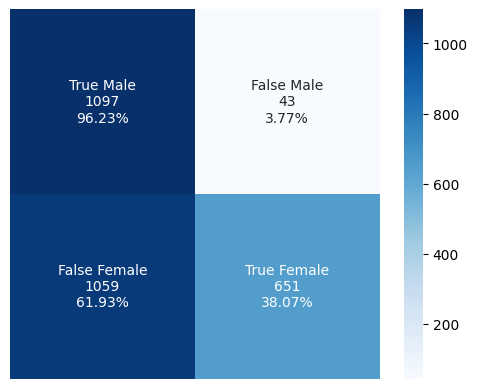

Run # 2


Accuracy,▁▇████████
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▆▅▄▃▃▂▂▁▁
test_acc,▁
val_Accuracy,▅█▆▁▁▅▇███
val_loss,█▇▆▅▄▃▂▂▁▁
Accuracy,0.99936
best_epoch,9
best_val_loss,5.71676
epoch,9
loss,3.68937


holaaaa, se metio al mask and bold
SE METIO AL DISTTTTTTTTTT
SE METIO AL LOGIN
sesions:  [3]
SESION:  3
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  65
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  49
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  50
Se metió al 68
j:  57
ENTRO AL SEGUNDO SUB BATCH
AHHHHHHHHHHHHHHHHHH [['R:/preprocess_batch-002/commonspace_bold/_scan_info_subject_id082.session03_split_name_sub-082_ses-03_desc-o_T2w/_run_None/sub-082_ses-03_task-dist_desc-oa_bold_autobox_combined.nii.gz', 'R:/preprocess_batch-002_rest/bold_datasink/commonspace_mask/_scan_info_subject_id082.session03_split_name_sub-082_ses-03_desc-o_T2w/_run_None/sub-082_ses-03_task-rest_desc-oa_bold_autobox_EPI_brain_mask.nii.gz'], ['R:/preprocess_batch-002/commonspace_bold/_scan_info_subject_id079.session03_split_name_sub-079_ses-03_desc-o_T2w/_run_None/sub-079_ses-03_task-dist_desc-oa_bold_autobox_combined.nii.gz', 'R:/pr

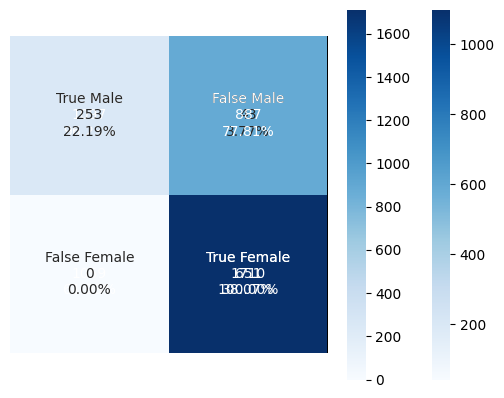

Run # 3


Accuracy,▁▁▃███████
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▆▅▄▃▃▂▂▁▁
test_acc,▁
val_Accuracy,▆▆▅▄▁▅█▆▇▅
val_loss,█▇▅▄▄▃▂▂▁▁
Accuracy,1
best_epoch,8
best_val_loss,5.12587
epoch,9
loss,3.61041


holaaaa, se metio al mask and bold
SE METIO AL DISTTTTTTTTTT
SE METIO AL LOGIN
sesions:  [3]
SESION:  3
Se metió al 68
j:  66
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  65
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  49
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  60
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
AHHHHHHHHHHHHHHHHHH [['R:/preprocess_batch-001/commonspace_bold/_scan_info_subject_id066.session03_split_name_sub-066_ses-03_desc-o_T2w/_run_None/sub-066_ses-03_task-dist_desc-oa_bold_autobox_combined.nii.gz', 'R:/preprocess_batch-001_rest/bold_datasink/commonspace_mask/_scan_info_subject_id066.session03_split_name_sub-066_ses-03_desc-o_T2w/_run_None/sub-066_ses-03_task-rest_desc-oa_bold_autobox_EPI_brain_mask.nii.gz'], ['R:/preprocess_batch-002/commonspace_bold/_scan_info_subject_id079.session03_split_name_sub-079_ses-03_desc-o_T2w/_run_None/sub-079_ses-03_task-dist_desc-oa_bold_autob

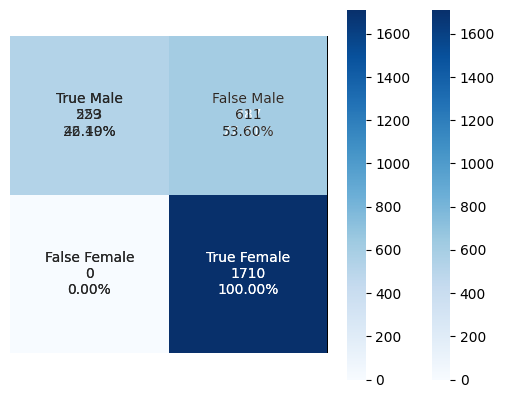

Run # 4


Accuracy,▁▁▆███████
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▆▅▄▃▃▂▂▁▁
test_acc,▁
val_Accuracy,██▆▂▃▃▁▃█▆
val_loss,█▇▆▅▄▄▃▂▁▁
Accuracy,1
best_epoch,8
best_val_loss,4.41319
epoch,9
loss,3.17609


holaaaa, se metio al mask and bold
SE METIO AL DISTTTTTTTTTT
SE METIO AL LOGIN
sesions:  [3]
SESION:  3
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  60
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  66
ENTRO AL SEGUNDO SUB BATCH
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  65
Se metió al 68
j:  57
ENTRO AL SEGUNDO SUB BATCH
Se metió al 68
j:  50
Se metió al 68
j:  49
ENTRO AL SEGUNDO SUB BATCH
AHHHHHHHHHHHHHHHHHH [['R:/preprocess_batch-002/commonspace_bold/_scan_info_subject_id080.session03_split_name_sub-080_ses-03_desc-o_T2w/_run_None/sub-080_ses-03_task-dist_desc-oa_bold_autobox_combined.nii.gz', 'R:/preprocess_batch-002_rest/bold_datasink/commonspace_mask/_scan_info_subject_id080.session03_split_name_sub-080_ses-03_desc-o_T2w/_run_None/sub-080_ses-03_task-rest_desc-oa_bold_autobox_EPI_brain_mask.nii.gz'], ['R:/preprocess_batch-001/commonspace_bold/_scan_info_subject_id060.session03_split_name_sub-060_ses-03_desc-o_T2w/_run_None/sub-060_ses-03_task-dist_desc-oa_bold_autobox_combine

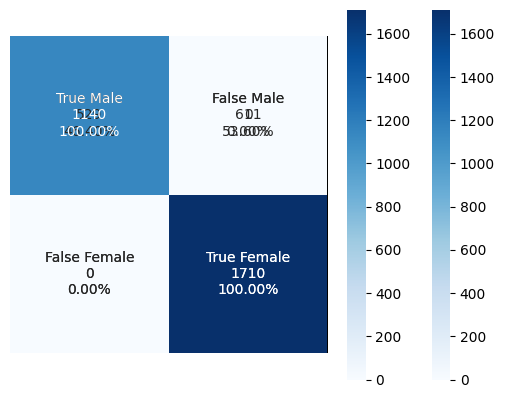

histories and scores from VGG 16 M2D


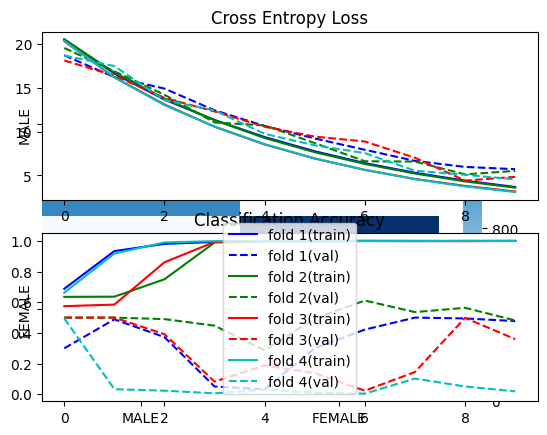

Accuracy: mean=77.193 std=14.515, n=4


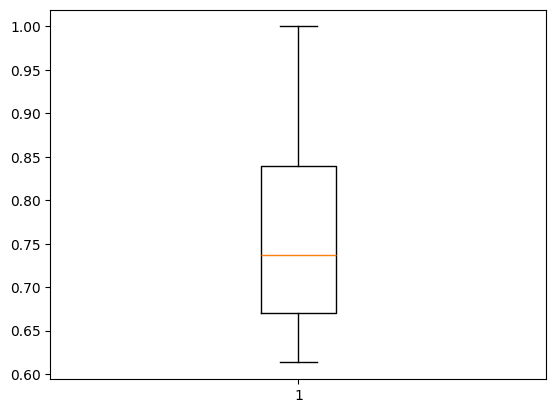

Accuracy,▁▆████████
epoch,▁▂▃▃▄▅▆▆▇█
loss,█▆▅▄▃▃▂▂▁▁
test_acc,▁
val_Accuracy,█▁▁▁▁▁▁▂▂▁
val_loss,█▇▅▅▄▃▂▁▁▁
Accuracy,0.99956
best_epoch,9
best_val_loss,4.55824
epoch,9
loss,3.11513


In [ ]:
# 80% train y val y 20% test
sub_trainval, sub_test, y_trainval, y_test = train_test_split(
    subjects, labels, test_size=0.2, random_state=42, stratify=labels
)

n_bootstraps= 1
for boot in range(n_bootstraps): 
    print(f"\n=== Bootstrapping Run {boot+1}/{n_bootstraps} ===")

    boot_subjects, boot_labels = resample(
        sub_trainval, y_trainval, replace=True, random_state=42+boot
    )

    kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

    scores, histories = list(), list()
    run = 1
    for train_ix, val_ix in kfold.split(boot_subjects, boot_labels):

        sub_train, sub_val = boot_subjects[train_ix], boot_subjects[val_ix]
        y_train, y_val     = boot_labels[train_ix], boot_labels[val_ix]

        sub_test, y_test = sub_test, y_test

        print("Run #",run)

        # Set default values
        config_defaults = {
            "batch": 1,
        }
        # Initialize wandb with a sample project name
        wandb.init(project="Male vs Female(GradCam) coverage", notes="FOLD "+str(run)+".  Evaluacion de male vs female con GradCam ++. lr = 1e-6",dir="C:/Users/103087364/wandb_runs"
                   ,config=config_defaults)

        # Specify the other hyperparameters to the configuration.
        wandb.config.epochs = 10
        wandb.config.sub_batch = 15
        wandb.config.sub_batch_ts = 15
        wandb.config.subjects = subjects
        wandb.config.architecture_name = "VGG16_3D"
        wandb.config.dataset_name = "Male vs Female, GradCam coverage"
        wandb.config.CNN_blocks = 5
        wandb.config.sessions = sessions
        wandb.config.vols_per_session_tr = 570#570
        wandb.config.vols_per_session_ts = 570#570
        wandb.config.initial_learning_rate = 1e-5
        #wandb.config.lr_decay_rate = 0.95
        wandb.config.optimizer = "Adam"
        
        
        val_size = max(2, int(round(0.1 * len(train_ix))))
    
        sub_train, sub_val, y_train, y_val = train_test_split(
            sub_trainval[train_ix], y_trainval[train_ix],
            test_size=val_size,  # test_size se refiere a la validacion
            random_state=42, stratify=y_trainval[train_ix]
        )
        
        CPHclassTrain = FILES_and_LABELS(sub_train, sessions, MRI_type, functional_type)
        CPHclassTest = FILES_and_LABELS(sub_test, sessions, MRI_type, functional_type)
        CPHclassval = FILES_and_LABELS(sub_val, sessions, MRI_type, functional_type)
            
        X_train = CPHclassTrain.get_mask_and_bold()
      
        print("X_train con exito")
        X_test = CPHclassTest.get_mask_and_bold()
        print("X_test con exito")
        X_val = CPHclassval.get_mask_and_bold()
        print("X_val con exito")

        print("sub train:")
        print(np.array(X_train)[:,0])
        print("sub test:")
        print(np.array(X_test)[:,0])
        print("sub val:")
        print(np.array(X_val)[:,0])

        print("# sesiones Train",len(X_train))
        print("# sesiones Test",len(X_test))
        print("# sesiones Val",len(X_val))
        
        traingen = CustomDataGen(X_train, batch_size=wandb.config.batch, subbatch_size=wandb.config.sub_batch,
                                format = "just_brain", vols = wandb.config.vols_per_session_tr,
                                num_class = 2, classes = "sex", augmentation = True, functional_type = "rest")
        traingen.on_epoch_end()
        #Es necesario que la division entre X_test y batch_size tenga un modulo igual a 0. 
        #De otra manera el ultimo batch no lo utiliza al utilizar .predict
        testgen  = CustomDataGen(X_test, batch_size=1,subbatch_size=wandb.config.sub_batch_ts,
                                format = "just_brain", vols= wandb.config.vols_per_session_ts,
                                num_class = 2, classes = "sex",shuffle=False, functional_type = "rest")
        valgen  = CustomDataGen(X_val, batch_size=len(X_val),subbatch_size=15, format = "just_brain",vols=570, augmentation = True, num_class = 2,
                                classes = "sex", functional_type = "rest")
        
        #getting model 3D CNN
        #callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, min_delta=0.0001)
        print("Starting VGG 16 3D-----------------------------------------------------")
        tf.keras.backend.clear_session()
        gc.collect()

        #transfer learning
        layers = [l for l in CNN.layers]
            
        for i in range(len(baseModel.layers)):
            layers[i].set_weights(baseModel.layers[i].get_weights())
            
        """
        lr_schedule = ExponentialDecay(wandb.config.initial_learning_rate,
                                    decay_steps=int((wandb.config.vols_per_session_tr/wandb.config.sub_batch)*len(X_train)),
                                    decay_rate=wandb.config.lr_decay_rate, staircase=True)
        """
        CNN.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=wandb.config.initial_learning_rate),
                        metrics=["Accuracy"])

        #checkpoint_filepath =os.getcwd()+"/"+wandb.run.name
        checkpoint_filepath = os.path.join("W:/", f"{wandb.run.name}.h5")
        #'/tmp/ckpt/MalevsFemale(CPH)_3D-VGG16_flips/'+wandb.run.name
        
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_loss', mode='min',
                                                                save_best_only=True)
        
        start_time = datetime.now()
        
        print("Training")

        print("Starting VGG 16 3D-----------------------------------------------------")
    # --- DEBUG: inspección del generador ---
        history = CNN.fit(traingen, epochs=wandb.config.epochs, validation_data = valgen, shuffle=True, callbacks=[SafeWandbCallback(monitor='val_loss',mode="min",save_model=False),model_checkpoint_callback])         
        end_time = datetime.now()
        print('Duration (CNN): {}'.format(end_time - start_time))

        y_test=[]
        x_vols = []
        for i in range(int(len(X_test)*(wandb.config.vols_per_session_ts/wandb.config.sub_batch_ts))):
            x,y = testgen[i]
            y_test.extend(y)
            x_vols.extend(x)
        y_test = np.argmax(y_test, axis=1)
        print("predicts CNN")
        preds = tf.cast(tf.argmax(CNN.predict(testgen), axis=1), tf.int32)
        #Wrong predicted subjects
        wrong_labeled_subj = mislabeled_subj(y_test, preds, X_test, wandb.config.vols_per_session_ts)

        print("mislabeled subjects:\n",wrong_labeled_subj)
        
        print("evaluating CNN")
        _,acc = CNN.evaluate(testgen, verbose=1)
        
        scores.append(acc)
        histories.append(history)
#---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        #Interpretability method: GradCam
        all_layers = [layer.name for layer in reversed(CNN.layers) if len(layer.output_shape) == 5 and (layer.__class__.__name__ == 'ReLU' or isinstance(layer, tf.keras.layers.Conv3D))] #Retrieves the names of all relevant 3D layers reversed to follow the order used for Grad-CAM++ processing
        index_male = index_for_gradcam(0,y_test,preds) #Gets the index of the male subject used for the Grad-CAM map
        index_female = index_for_gradcam(1,y_test,preds)
        data_grad = data_grad_completo[3:45, 4:69, 7:36]
        Writer = animation.writers['ffmpeg']
        writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)

        if index_male != None:
            heatmap_male = make_gradcam_heatmap(np.expand_dims(x_vols[index_male], axis=0), CNN, all_layers[0])
            #Matches the heatmap dimensions to the reference volume by adding or removing axes
            while heatmap_male.ndim < data_grad_completo.ndim:
                heatmap_male = np.expand_dims(heatmap_male, axis=-1)
            if heatmap_male.ndim > data_grad_completo.ndim:
                heatmap_male = np.squeeze(heatmap_male)

            if heatmap_male.shape != data_grad_completo.shape:
                factor_m = np.array(data_grad_completo.shape) / np.array(heatmap_male.shape)
                resized_heatmap_male = zoom(heatmap_male, factor_m, order=1)
            else:
                resized_heatmap_male = heatmap_male.copy()

            resized_heatmap_male = (resized_heatmap_male - resized_heatmap_male.min()) / (resized_heatmap_male.max() - resized_heatmap_male.min() + 1e-8) # Normalizes the heatmap to a 0-1 range for consistent analysis.

            heatmap_norm_male = resized_heatmap_male.astype(np.float32) #Converts to float32 for numerical stability
            thr_male = np.percentile(heatmap_norm_male, 90)  #Computes the threshold corresponding to the top 10% most intense activations
            salient_male = heatmap_norm_male >= thr_male  #Creates a binary mask (only leaves the most intense activations)

            activation_voxels_male = salient_male.sum() #Counts the total activations
            voxels_inside_male = np.logical_and(salient_male, mask).sum() #Counts how many of those activations actually fall inside the brain mask

            coverage_male = voxels_inside_male / activation_voxels_male #Calculates the coverage (voxels inside the brain respect to the total activationes)
            print("Coverage male:", coverage_male)

            #name_ani_male = "GradCam_male(malevsfemale-CPH)-"+wandb.run.name+".mp4"
            #gradcam_male.save(name_ani_male, writer=writer)
            
            #output_dir = "E:"
            #os.makedirs(output_dir, exist_ok=True)
            #name_ani_male = os.path.join(output_dir, "GradCam_male(malevsfemale-CPH)-" + wandb.run.name + ".mp4")
            #gradcam_male.save(name_ani_male, writer=writer)
            
            #GradCam average all conv layers
            #print("GradCam All ConvLayers-male")

            #all_layers_gradcam_male = fuse_layers(all_layers, CNN, x_vols, index_male, emphasize=False)
            #all_layers_animation_male = create_animation(data_grad, 'All_layers_GradCam_male', heatmap=all_layers_gradcam_male) #Cambio requerido, muchos sujetos
            #name_all_male = 'All_layers_GradCam_male'+wandb.run.name+'.mp4'
            #name_all_male = os.path.join(output_dir, "All_layers_GradCam_male" + wandb.run.name + ".mp4")
            #all_layers_animation_male.save(name_all_male, writer=writer)

            #males
            #if not os.path.exists("W:"+"/"+wandb.run.name+"/male"): 
                # if the demo_folder directory is not present  
                # then create it. 
                #os.makedirs("W:"+"/"+wandb.run.name+"/male")
            for i in range(len(x_vols[index_male][0,:,0])):
                plt.imshow(cv2.resize(np.rot90(np.array(data_grad)[:,i,:]),dsize=(126,87)), alpha=0.8, cmap='bone')
                # over the cam output
                #plt.imshow(cv2.resize(np.rot90(resized_heatmap_female[:,i,:]),dsize=(126,87)), alpha=0.4,cmap='jet')
                plt.imshow(cv2.resize(np.rot90(np.where(resized_heatmap_male[:, i, :] > np.percentile(resized_heatmap_male, 90),resized_heatmap_male[:, i, :], np.nan)),dsize=(126, 87)),cmap='Reds',alpha=1.0)
                plt.axis('off')
                # display the image
                
                #name = str(i)+".png" 
                #plt.savefig("W:"+"/"+wandb.run.name+"/female/"+name)
                #plt.show()
           
            
            #np.save("W:"+"/"+wandb.run.name+"/male/Array_GradCam-M", full_grad_male)
            
            #wandb.log({'GradCam_Male-coronal': wandb.Video(name_ani_male),
                #'GradCam_Male_all-layers': wandb.Video(name_all_male),
                #'GradCam-per_frames-male': wandb.Image(grad_cam_per_frames(data_grad,resized_heatmap_male, 150))})
        
        #The same logic applies for the female case.”
        if index_female != None:
            heatmap_female = make_gradcam_heatmap(np.expand_dims(x_vols[index_female], axis=0), CNN, all_layers[0]) 

            while heatmap_female.ndim < data_grad_completo.ndim:
                heatmap_female = np.expand_dims(heatmap_female, axis=-1)

            if heatmap_female.ndim > data_grad_completo.ndim:
                heatmap_female = np.squeeze(heatmap_female)

            if heatmap_female.shape != data_grad_completo.shape:
                factor_f = np.array(data_grad_completo.shape) / np.array(heatmap_female.shape)
                resized_heatmap_female = zoom(heatmap_female, factor_f, order=1)
            else:
                resized_heatmap_female = heatmap_female.copy()

            resized_heatmap_female = (resized_heatmap_female - resized_heatmap_female.min()) / (resized_heatmap_female.max() - resized_heatmap_female.min() + 1e-8)
            
            heatmap_norm = resized_heatmap_female.astype(np.float32)
            thr = np.percentile(heatmap_norm, 90)
            salient = heatmap_norm >= thr

            activation_voxels = salient.sum()
            voxels_inside = np.logical_and(salient, mask).sum()

            coverage_female = voxels_inside / activation_voxels
            print("Coverage female:", coverage_female)
            
            #gradcam_female = create_animation(data_grad, 'Female', heatmap=resized_heatmap_female)
            #name_ani_female = "GradCam_female(malevsfemale-CPH)-"+wandb.run.name+".mp4"
            #gradcam_female.save(name_ani_female, writer=writer)

            #output_dir = "E:"
            #name_ani_female = os.path.join(output_dir, "GradCam_female(malevsfemale-CPH)-" + wandb.run.name + ".mp4")
            #gradcam_female.save(name_ani_female, writer=writer)
            
            #GradCam average all conv layers
            #print("GradCam All ConvLayers-female")
        
            #all_layers_gradcam_female = fuse_layers(all_layers, CNN, x_vols, index_female, emphasize=False)
            #all_layers_animation_female = create_animation(data_grad, 'All_layers_GradCam_female', heatmap=all_layers_gradcam_female)
            #name_all_female = 'All_layers_GradCam_female'+wandb.run.name+'.mp4'
            #name_all_female = os.path.join(output_dir, "All_layers_GradCam_female" + wandb.run.name + ".mp4")
            #all_layers_animation_female.save(name_all_female, writer=writer)
        
            #Save frame by frame of gradcam
            #Females
            #if not os.path.exists("W:"+"/"+wandb.run.name+"/female"): 
                # if the demo_folder directory is not present  
                # then create it. 
                #os.makedirs("W:"+"/"+wandb.run.name+"/female")
            
            for i in range(len(x_vols[index_female][0,:,0])):
                plt.imshow(cv2.resize(np.rot90(np.array(data_grad)[:,i,:]),dsize=(126,87)), alpha=0.8, cmap='bone')
                # over the cam output
                #plt.imshow(cv2.resize(np.rot90(resized_heatmap_female[:,i,:]),dsize=(126,87)), alpha=0.4,cmap='jet')
                plt.imshow(cv2.resize(np.rot90(np.where(resized_heatmap_female[:, i, :] > np.percentile(resized_heatmap_female, 90),resized_heatmap_female[:, i, :], np.nan)),dsize=(126, 87)),cmap='Reds',alpha=1.0)
                plt.axis('off')
                # display the image
                
                #name = str(i)+".png" 
                #plt.savefig("W:"+"/"+wandb.run.name+"/female/"+name)
                #plt.show()
        
            
            #get gradCams with the shape of the original volumes before crop
            

            #full_grad_female = np.zeros((48,81,48))
            #full_grad_female[3:45,4:69,7:36] = resized_heatmap_female
            #np.save("W:"+"/"+wandb.run.name+"/female/Array_GradCam-F", full_grad_female)
            
            #wandb.log({'GradCam-Female-coronal': wandb.Video(name_ani_female),
                #'GradCam-Female_all-layers': wandb.Video(name_all_female),
                #'GradCam-per_frames-female': wandb.Image(grad_cam_per_frames(data_grad,resized_heatmap_female, 150))})
            

        print("CM CNN")
        cm = confusionmatrix(y_test, preds)

        wandb.log({'test_acc': float(acc),
                'time_running': '{}'.format(end_time - start_time),
                'confution_matrix': wandb.Image(cm),
                'mislabeled_subj':wrong_labeled_subj})
        

        run = run + 1
        
    print("histories and scores from VGG 16 M2D") 
    summarize_diagnostics(histories)
    summarize_performance(scores)

    wandb.finish()
        

In [17]:
resized_heatmap_male = (resized_heatmap_male - resized_heatmap_male.min()) / (resized_heatmap_male.max() - resized_heatmap_male.min() + 1e-8)

heatmap_norm_male = resized_heatmap_male.astype(np.float32)
thr_male = np.percentile(heatmap_norm_male, 90)
salient_male = heatmap_norm_male >= thr_male

activation_voxels_male = salient_male.sum()
voxels_inside_male = np.logical_and(salient_male, mask).sum()
coverage_male = voxels_inside_male / activation_voxels_male
print("Coverage male:", coverage_male)


ValueError: operands could not be broadcast together with shapes (42,65,29) (48,81,48) 

In [ ]:
# 80% train y val y 20% test
sub_trainval, sub_test, y_trainval, y_test = train_test_split(
    subjects, labels, test_size=0.2, random_state=42, stratify=labels
)

n_bootstraps= 1
for boot in range(n_bootstraps): 
    print(f"\n=== Bootstrapping Run {boot+1}/{n_bootstraps} ===")

    boot_subjects, boot_labels = resample(
        sub_trainval, y_trainval, replace=True, random_state=42+boot
    )

    kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

    scores, histories = list(), list()
    run = 1
    for train_ix, val_ix in kfold.split(boot_subjects, boot_labels):

        sub_train, sub_val = boot_subjects[train_ix], boot_subjects[val_ix]
        y_train, y_val     = boot_labels[train_ix], boot_labels[val_ix]

        sub_test, y_test = sub_test, y_test

        print("Run #",run)

        # Set default values
        config_defaults = {
            "batch": 1,
        }
        # Initialize wandb with a sample project name
        wandb.init(project="Male vs Female(grad++) coverage", notes="FOLD "+str(run)+".  Evaluacion de male vs female con GradCam ++. lr = 1e-6",dir="C:/Users/103087364/wandb_runs"
                   ,config=config_defaults)

        # Specify the other hyperparameters to the configuration.
        wandb.config.epochs = 2
        wandb.config.sub_batch = 15
        wandb.config.sub_batch_ts = 15
        wandb.config.subjects = subjects
        wandb.config.architecture_name = "VGG16_3D"
        wandb.config.dataset_name = "Male vs Female, plus GradCam++ coverage"
        wandb.config.CNN_blocks = 5
        wandb.config.sessions = sessions
        wandb.config.vols_per_session_tr = 570#570
        wandb.config.vols_per_session_ts = 570#570
        wandb.config.initial_learning_rate = 1e-5
        #wandb.config.lr_decay_rate = 0.95
        wandb.config.optimizer = "Adam"
        
        
        val_size = max(2, int(round(0.1 * len(train_ix))))
    
        sub_train, sub_val, y_train, y_val = train_test_split(
            sub_trainval[train_ix], y_trainval[train_ix],
            test_size=val_size,  # test_size se refiere a la validacion
            random_state=42, stratify=y_trainval[train_ix]
        )
        
        CPHclassTrain = FILES_and_LABELS(sub_train, sessions, MRI_type, functional_type)
        CPHclassTest = FILES_and_LABELS(sub_test, sessions, MRI_type, functional_type)
        CPHclassval = FILES_and_LABELS(sub_val, sessions, MRI_type, functional_type)
            
        X_train = CPHclassTrain.get_mask_and_bold()
      
        print("X_train con exito")
        X_test = CPHclassTest.get_mask_and_bold()
        print("X_test con exito")
        X_val = CPHclassval.get_mask_and_bold()
        print("X_val con exito")

        print("sub train:")
        print(np.array(X_train)[:,0])
        print("sub test:")
        print(np.array(X_test)[:,0])
        print("sub val:")
        print(np.array(X_val)[:,0])

        print("# sesiones Train",len(X_train))
        print("# sesiones Test",len(X_test))
        print("# sesiones Val",len(X_val))
        
        traingen = CustomDataGen(X_train, batch_size=wandb.config.batch, subbatch_size=wandb.config.sub_batch,
                                format = "just_brain", vols = wandb.config.vols_per_session_tr,
                                num_class = 2, classes = "sex", augmentation = True, functional_type = "rest")
        traingen.on_epoch_end()
        #Es necesario que la division entre X_test y batch_size tenga un modulo igual a 0. 
        #De otra manera el ultimo batch no lo utiliza al utilizar .predict
        testgen  = CustomDataGen(X_test, batch_size=1,subbatch_size=wandb.config.sub_batch_ts,
                                format = "just_brain", vols= wandb.config.vols_per_session_ts,
                                num_class = 2, classes = "sex",shuffle=False, functional_type = "rest")
        valgen  = CustomDataGen(X_val, batch_size=len(X_val),subbatch_size=15, format = "just_brain",vols=570, augmentation = True, num_class = 2,
                                classes = "sex", functional_type = "rest")
        
        #getting model 3D CNN
        #callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, min_delta=0.0001)
        print("Starting VGG 16 3D-----------------------------------------------------")
        tf.keras.backend.clear_session()
        gc.collect()

        #transfer learning
        layers = [l for l in CNN.layers]
            
        for i in range(len(baseModel.layers)):
            layers[i].set_weights(baseModel.layers[i].get_weights())
            
        """
        lr_schedule = ExponentialDecay(wandb.config.initial_learning_rate,
                                    decay_steps=int((wandb.config.vols_per_session_tr/wandb.config.sub_batch)*len(X_train)),
                                    decay_rate=wandb.config.lr_decay_rate, staircase=True)
        """
        CNN.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=wandb.config.initial_learning_rate),
                        metrics=["Accuracy"])

        #checkpoint_filepath =os.getcwd()+"/"+wandb.run.name
        checkpoint_filepath = os.path.join("W:/", f"{wandb.run.name}.h5")
        #'/tmp/ckpt/MalevsFemale(CPH)_3D-VGG16_flips/'+wandb.run.name
        
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_loss', mode='min',
                                                                save_best_only=True)
        
        start_time = datetime.now()
        
        print("Training")

        print("Starting VGG 16 3D-----------------------------------------------------")
    # --- DEBUG: inspección del generador ---
        history = CNN.fit(traingen, epochs=wandb.config.epochs, validation_data = valgen, shuffle=True, callbacks=[SafeWandbCallback(monitor='val_loss',mode="min",save_model=False),model_checkpoint_callback])         
        end_time = datetime.now()
        print('Duration (CNN): {}'.format(end_time - start_time))

        y_test=[]
        x_vols = []
        for i in range(int(len(X_test)*(wandb.config.vols_per_session_ts/wandb.config.sub_batch_ts))):
            x,y = testgen[i]
            y_test.extend(y)
            x_vols.extend(x)
        y_test = np.argmax(y_test, axis=1)
        print("predicts CNN")
        preds = tf.cast(tf.argmax(CNN.predict(testgen), axis=1), tf.int32)
        #Wrong predicted subjects
        wrong_labeled_subj = mislabeled_subj(y_test, preds, X_test, wandb.config.vols_per_session_ts)

        print("mislabeled subjects:\n",wrong_labeled_subj)
        
        print("evaluating CNN")
        _,acc = CNN.evaluate(testgen, verbose=1)
        
        scores.append(acc)
        histories.append(history)

        #HiresCam
        last_conv_layer_name = 'conv3d_25'
        hirescam = HiResCAM(model=CNN, last_conv_layer_name=last_conv_layer_name)
        index_male = index_for_gradcam(0, y_test, preds)
        index_female = index_for_gradcam(1, y_test, preds)

        if index_female is not None:
            x_female = np.expand_dims(x_vols[index_female], axis=0)
            heatmap_female = hirescam.get_cam(x_female, pred_index=1)
            while heatmap_female.ndim < data_grad_completo.ndim:
                heatmap_female = np.expand_dims(heatmap_female, axis=-1)
            if heatmap_female.ndim > data_grad_completo.ndim:
                heatmap_female = np.squeeze(heatmap_female)
            if heatmap_female.shape != data_grad_completo.shape:
                factor_f = np.array(data_grad_completo.shape) / np.array(heatmap_female.shape)
                heatmap_female = zoom(heatmap_female, factor_f, order=1)
            heatmap_female = (heatmap_female - heatmap_female.min()) / (heatmap_female.max() - heatmap_female.min() + 1e-8)
            for i in range(heatmap_female.shape[1]):
                plt.imshow(np.rot90(data_grad_completo[:, i, :]), cmap='gray')
                thr = np.percentile(heatmap_female, 90)
                plt.imshow(np.rot90(np.where(heatmap_female[:, i, :] > thr, heatmap_female[:, i, :], np.nan)), cmap='Reds', alpha=1.0)
                plt.axis('off')
                plt.tight_layout()
                plt.show()

            crop_slice = (slice(3,45), slice(4,69), slice(7,36))
            crop_shape = (45-3, 69-4, 36-7)

            original_hmap_female = heatmap_female

            original_shape_female = original_hmap_female.shape
            factor = np.array(crop_shape) / np.array(original_shape_female)

            heatmap_female_original_resized_for_save = zoom(original_hmap_female, factor, order=1)

            full_grad_female = np.zeros((48,81,48))
            full_grad_female[crop_slice] = heatmap_female_original_resized_for_save

            save_dir_female = f"W:/{wandb.run.name}/female"
            os.makedirs(save_dir_female, exist_ok=True)

            np.save(f"{save_dir_female}/Array_GradCamplusplus-F.npy", full_grad_female)
    

        if index_male is not None:
            x_male = np.expand_dims(x_vols[index_male], axis=0)
            heatmap_male = hirescam.get_cam(x_male, pred_index=0)
            while heatmap_male.ndim < data_grad_completo.ndim:
                heatmap_male = np.expand_dims(heatmap_male, axis=-1)
            if heatmap_male.ndim > data_grad_completo.ndim:
                heatmap_male = np.squeeze(heatmap_male)
            if heatmap_male.shape != data_grad_completo.shape:
                factor_m = np.array(data_grad_completo.shape) / np.array(heatmap_male.shape)
                heatmap_male = zoom(heatmap_male, factor_m, order=1)
            heatmap_male = (heatmap_male - heatmap_male.min()) / (heatmap_male.max() - heatmap_male.min() + 1e-8)
            for i in range(heatmap_male.shape[1]):
                plt.imshow(np.rot90(data_grad_completo[:, i, :]), cmap='gray')
                thr = np.percentile(heatmap_male, 90)
                plt.imshow(np.rot90(np.where(heatmap_male[:, i, :] > thr, heatmap_male[:, i, :], np.nan)), cmap='Reds', alpha=1.0)
                plt.axis('off')
                plt.tight_layout()
                plt.show()
        
            crop_slice = (slice(3,45), slice(4,69), slice(7,36))
            crop_shape = (45-3, 69-4, 36-7)

            original_hmap = heatmap_male 
            original_shape = original_hmap.shape

            factor = np.array(crop_shape) / np.array(original_shape)
            heatmap_male_original_resized_for_save = zoom(original_hmap, factor, order=1)

            full_grad_male = np.zeros((48,81,48))
            full_grad_male[crop_slice] = heatmap_male_original_resized_for_save

            save_dir = f"W:/{wandb.run.name}/male"
            os.makedirs(save_dir, exist_ok=True)

            np.save(f"{save_dir}/Array_GradCamplusplus-M.npy", full_grad_male)

        print("CM CNN")
        cm = confusionmatrix(y_test, preds)
            
        wandb.log({'test_acc': float(acc),
                'time_running': '{}'.format(end_time - start_time),
                'confution_matrix': wandb.Image(cm),
                'mislabeled_subj':wrong_labeled_subj})
        run = run + 1
        
    print("histories and scores from VGG 16 M2D") 
    summarize_diagnostics(histories)
    summarize_performance(scores)

    wandb.finish()
        

In [ ]:

crop_slice = (slice(3,45), slice(4,69), slice(7,36))
crop_shape = (45-3, 69-4, 36-7)  # (42,65,29)
original_hmap = heatmap_male[0]            
original_shape = original_hmap.shape       
factor = np.array(crop_shape) / np.array(original_shape)
resized_heatmap_male = zoom(original_hmap, factor, order=1)
full_grad_male = np.zeros((48,81,48))
full_grad_male[crop_slice] = resized_heatmap_male
save_dir = f"W:/{wandb.run.name}/male"
os.makedirs(save_dir, exist_ok=True)

np.save(f"{save_dir}/Array_GradCamplusplus-M.npy", full_grad_male)

print("Guardado exitoso. Shape final:", full_grad_male.shape)

In [ ]:
#mask_nii = nib.load("R:/rabies/preprocess_batch-001_rest/bold_datasink/commonspace_mask/_scan_info_subject_id057.session01_split_name_sub-057_ses-01_desc-o_T2w/_run_None/sub-057_ses-01_task-rest_desc-oa_bold_autobox_EPI_brain_mask.nii.gz")
mask_nii =  nib.load("C:/Users/l03087364/Downloads/Kerensa Sierra_EI/sigma_files/sigma_files/SIGMA_resam_syn_waxholm_atlas.nii")
mask = mask_nii.get_fdata()
mask = mask > 0
print("Mask shape:", mask.shape)
heatmap = np.load("C:/Users/l03087364/Downloads/Kerensa Sierra_EI/etheral_pyramid-579.npy")
heatmap_norm = heatmap.astype(np.float32) / 255.0 #Considerando que abarcaba hasta el 255
thr = np.percentile(heatmap_norm, 90) #Determines the value in which 10% of the voxels are the most higher
salient = heatmap_norm >= thr #Binary maps that mark the highest activations
#Determination of the convergence in the brain area
activation_voxels = salient.sum() #How many voxels are active
voxels_inside = np.logical_and(salient, mask).sum() #How many voxels inside are activated, sum() counts how many results are positive
coverage = voxels_inside / activation_voxels #Metric that establishes, the ratio of the voxels within the area of the brain
print("Coverage:", coverage)
for i in range(heatmap.shape[1]):
    plt.imshow(np.rot90(data_grad_completo[:, i, :]), cmap='gray')
    plt.imshow(np.rot90(np.where(heatmap[:, i, :] > np.percentile(heatmap, 90),heatmap[:, i, :], np.nan)),cmap='Reds',alpha=1.0)
    plt.axis('off')
    plt.tight_layout()
    plt.show()